## Extra-Trees

In this part we train Extremely Randomized Trees (Extra-Trees). As in the random forest, each split only considers a random subset of the inputs, but the threshold of each input is also drawn at random instead of being optimised, and each tree is grown on all the training rows instead of a bootstrap sample.

### Main observations

- **Number of trees:** 200 trees, as for the other ensembles. A single Extra-Tree is already better than a single bagged tree (46.6 against 50.8 MPa on the yield strength), as it is grown on all the rows.
- **Hyperparameters:** `max_features` of 0.5 for the tensile targets and 1.0 for Charpy, with fully grown trees. On every cell of the grid with `min_samples_leaf = 1`, the Extra-Trees are below the random forest.
- **Results:** The best tree model on every target: MAE of 29.1 MPa on the yield strength, 25.2 MPa on the UTS, 1.79% on the elongation and 17.4 J on the Charpy energy, 8% to 15% below the random forest and 55% to 66% below the baseline. On the label, F1 of 0.84 (the best of the tree models) and recall of 0.72.
- **Why better than the random forest:** Mostly the random thresholds. With the same bootstrap as the random forest, the Extra-Trees are still 3.6 MPa below it on the yield strength. Dropping the bootstrap mainly matters on Charpy.
- **Charpy:** As for the other ensembles, the averaged predictions rarely fall below the threshold at the reference temperature, and only 17% of the non-conforming Charpy rows are caught.
- **Important inputs:** Cr, Mo, Mn and V for the tensile targets, and the test temperature, far ahead of the rest, for Charpy.

### Operations in order

1. Load the train set with `load_train`.
2. Plot the validation MAE against the number of trees, to fix `n_estimators`.
3. Tune `max_features` and `min_samples_leaf` per target by a grid search on the folds of `helpers/utils.py`, with the same grid as the random forest.
4. Evaluate the best model of each target with `evaluate`, and compare the spread of its predictions with the measures.
5. Save it to `results.csv` and compare it with the other tree models.
6. Cross-validate the random forest and the Extra-Trees with and without bootstrap, to see where the gain of the Extra-Trees comes from.
7. Compute the permutation importance of each input on the validation folds.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.inspection import permutation_importance
from sklearn.model_selection import GridSearchCV, cross_val_score, validation_curve

import sys
sys.path.append("..")  # helpers/ is in modeling/

from helpers.utils import (
    SEED, TARGETS, load_train, get_xy, build_pipeline,
    oof_predict, true_criteria, predicted_criteria, evaluate, save_results,
)

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_rows", None)

In [3]:
train = load_train()

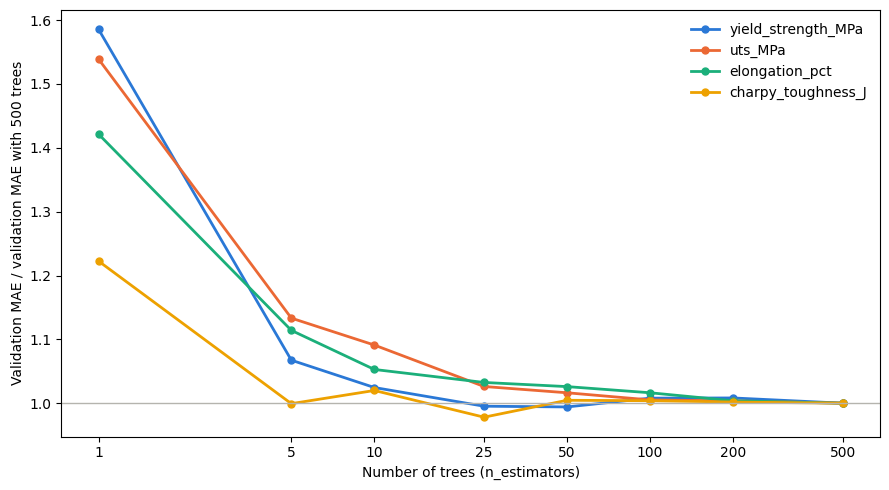

,yield_strength_MPa,uts_MPa,elongation_pct,charpy_toughness_J
n_estimators,,,,
1,46.59,39.19,2.56,21.25
5,31.37,28.86,2.01,17.37
10,30.11,27.79,1.90,17.73
25,29.25,26.14,1.86,17.00
50,29.21,25.89,1.85,17.46
100,29.62,25.60,1.83,17.45
200,29.63,25.56,1.81,17.42
500,29.39,25.47,1.80,17.38


In [4]:
n_trees = [1, 5, 10, 25, 50, 100, 200, 500]

curves = {}
for target in TARGETS:
    X, y, cv = get_xy(train, target)
    _, val_scores = validation_curve(
        build_pipeline(ExtraTreesRegressor(random_state=SEED)),
        X, y,
        param_name="model__n_estimators",
        param_range=n_trees,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    curves[target] = -val_scores.mean(axis=1)
curves = pd.DataFrame(curves, index=pd.Index(n_trees, name="n_estimators"))

fig, ax = plt.subplots(figsize=(9, 5))
for color, target in zip(["#2a78d6", "#eb6834", "#1baf7a", "#eda100"], TARGETS):
    ax.plot(n_trees, curves[target] / curves[target].iloc[-1], color=color, linewidth=2, marker="o", markersize=5, label=target)
ax.axhline(1, color="#b5b4ae", linewidth=1)
ax.set_xscale("log")
ax.set_xticks(n_trees, n_trees)
ax.minorticks_off()
ax.set_xlabel("Number of trees (n_estimators)")
ax.set_ylabel("Validation MAE / validation MAE with 500 trees")
ax.legend(frameon=False)
plt.tight_layout()
plt.show()

curves.round(2)

Same curve as in the bagging and random forest notebooks, with the default `ExtraTreesRegressor` (`max_features = 1.0`, no bootstrap).

- **1 tree:** 46.6 MPa on the yield strength, less than a single bagged tree (50.8 MPa) or a single tree of the random forest (52.9 MPa): an Extra-Tree is grown on all the rows of the train folds.
- **More trees:** The curves flatten from 25 trees on (100 trees for the elongation), and every target is within 1% of its value at 500 trees with 200 trees, the number kept as for the other ensembles.

In [5]:
param_grid = {"model__max_features": [0.1, 0.2, 0.33, 0.5, 0.75, 1.0], "model__min_samples_leaf": [1, 2, 4, 8]}

searches = {}
for target in TARGETS:
    X, y, cv = get_xy(train, target)
    search = GridSearchCV(
        build_pipeline(ExtraTreesRegressor(n_estimators=200, random_state=SEED)),
        param_grid,
        cv=cv,
        scoring="neg_mean_absolute_error",
        n_jobs=-1,
    )
    search.fit(X, y)
    searches[target] = search

grid = pd.concat({
    target: pd.DataFrame(search.cv_results_).pivot(index="param_model__min_samples_leaf", columns="param_model__max_features", values="mean_test_score")
    for target, search in searches.items()
})
(-grid).rename_axis(index=["target", "min_samples_leaf"], columns="max_features").round(2)

max_features                          0.10   0.20   0.33   0.50   0.75   1.00
target             min_samples_leaf                                          
yield_strength_MPa 1                 32.63  30.24  29.28  29.05  29.25  29.63
                   2                 40.28  34.31  31.95  30.95  30.89  31.25
                   4                 49.36  40.78  37.33  34.98  34.53  34.31
                   8                 56.99  48.72  44.67  41.65  40.41  39.92
uts_MPa            1                 29.10  26.56  25.82  25.19  25.22  25.56
                   2                 35.91  30.10  28.23  26.80  26.74  26.80
                   4                 44.82  36.09  33.50  31.07  30.60  30.27
                   8                 52.33  43.45  39.95  37.10  35.66  35.40
elongation_pct     1                  1.94   1.82   1.80   1.78   1.79   1.81
                   2                  2.27   2.00   1.90   1.83   1.83   1.84
                   4                  2.72   2.28   2.10   1.99   1.96   1.94
                   8                  3.10   2.64   2.45   2.27   2.21   2.17
charpy_toughness_J 1                 18.92  18.53  18.09  17.59  17.50  17.42
                   2                 27.07  23.44  21.27  19.70  18.68  18.30
                   4                 31.03  27.28  24.50  22.40  20.61  20.12
                   8                 33.39  30.15  27.88  25.62  23.84  23.09

The validation MAE of each pair (`min_samples_leaf`, `max_features`), with 200 trees, on the same grid as the random forest.

- **Compared with the random forest:** Lower on every cell with `min_samples_leaf = 1`: 29.1 MPa against 33.9 MPa on the yield strength at `max_features = 0.5`, 17.4 J against 19.1 J on Charpy at 1.0.
- **max_features:** Flat between 0.33 and 1.0 as for the random forest, and up at 0.1. On Charpy, the MAE keeps decreasing up to 1.0 (17.4 J): the more inputs are drawn, the more often the test temperature, its main input (see the permutation importance below), is available at a split.
- **min_samples_leaf:** The MAE goes up faster than for the random forest, from 29.1 to 31.0, 35.0 and 41.7 MPa on the yield strength (with `max_features = 0.5`). As for the random forest, fully grown trees are the best.

In [6]:
best = {target: search.best_estimator_ for target, search in searches.items()}

pd.DataFrame({
    target: {**{name.removeprefix("model__"): value for name, value in search.best_params_.items()}, "validation_MAE": -search.best_score_}
    for target, search in searches.items()
}).T

,max_features,min_samples_leaf,validation_MAE
yield_strength_MPa,0.5,1.0,29.049930
uts_MPa,0.5,1.0,25.190310
elongation_pct,0.5,1.0,1.783821
charpy_toughness_J,1.0,1.0,17.415860


`max_features` of 0.5 for the three tensile targets and 1.0 for Charpy, with fully grown trees for the four targets. The validation MAE is 29.0 MPa on the yield strength, 25.2 MPa on the UTS, 1.78% on the elongation and 17.4 J on Charpy, from 8% to 15% below the random forest.

In [7]:
extra_trees = evaluate("Extra-Trees", best, train)
extra_trees.round(2)

,model,target,family,n,MAE,RMSE,MAE_std,RMSE_std,n_clf,n_nc,F1_nc,recall_nc,accuracy
0,Extra-Trees,yield_strength_MPa,all,620,29.08,42.49,2.80,7.64,619,102,0.78,0.65,0.94
1,Extra-Trees,yield_strength_MPa,C-Mn,552,27.08,36.87,1.63,3.95,552,102,0.78,0.65,0.93
2,Extra-Trees,yield_strength_MPa,CrMo2,30,44.72,75.69,39.87,50.95,29,0,0.00,0.00,1.00
3,Extra-Trees,yield_strength_MPa,CrMo91,38,45.72,71.97,18.57,32.84,38,0,0.00,0.00,1.00
4,Extra-Trees,uts_MPa,all,596,25.24,38.84,3.24,9.46,595,198,0.74,0.61,0.86
5,Extra-Trees,uts_MPa,C-Mn,531,23.12,31.78,1.79,2.78,531,198,0.74,0.61,0.84
6,Extra-Trees,uts_MPa,CrMo2,34,45.74,79.49,34.55,52.28,33,0,0.00,0.00,1.00
7,Extra-Trees,uts_MPa,CrMo91,31,38.93,69.04,18.47,39.36,31,0,0.00,0.00,1.00
8,Extra-Trees,elongation_pct,all,558,1.79,2.36,0.17,0.26,557,48,0.72,0.60,0.96
9,Extra-Trees,elongation_pct,C-Mn,497,1.76,2.29,0.11,0.12,497,37,0.75,0.65,0.97


- **MAE:** 29.1 MPa on the yield strength, 25.2 MPa on the UTS, 1.79% on the elongation and 17.4 J on the Charpy energy: the lowest of the four tree models on every target, from 55% (elongation) to 66% (UTS) below the baseline.
- **Per family:** On the C-Mn welds, 27.1 MPa on the yield strength and 13.9 J on Charpy. The Cr-Mo welds stay much worse: 44.7 MPa on the yield strength of the CrMo2 welds, and 46.3 J on their Charpy energy.
- **F1, recall per criterion:** The best F1 of the tree models on the three tensile criteria (0.78, 0.74 and 0.72). On Charpy, the recall stays at 0.17, as for the other ensembles.
- **label:** F1 of 0.84 and recall of 0.72, the best F1 of the tree models, with the same recall as the bagging.

In [8]:
preds = {target: oof_predict(best[target], train, target) for target in TARGETS}
criteria = true_criteria(train)
predicted = predicted_criteria(train, preds)

pd.DataFrame({
    "std_measured": [get_xy(train, target)[1].std() for target in TARGETS],
    "std_predicted": [preds[target]["pred"].std() for target in TARGETS],
    "non_conforming": (criteria == 0).sum(),
    "predicted_non_conforming": ((predicted == 0) & criteria.notna()).sum(),
}, index=TARGETS).round(1)

,std_measured,std_predicted,non_conforming,predicted_non_conforming
yield_strength_MPa,94.2,78.3,102,67
uts_MPa,91.9,77.7,198,130
elongation_pct,4.8,4.0,48,32
charpy_toughness_J,51.5,43.6,29,8


The same table as in the other tree notebooks.

- **std_predicted:** Close to the bagging and the random forest (78.3 against 94.2 MPa on the yield strength): the Extra-Trees smooth the predictions in the same way.
- **predicted_non_conforming:** More predicted failures than the random forest on the tensile criteria (67 against 54 on the yield strength, for 102 non-conforming rows), and they are almost always right (66 of the 67 on the yield strength), hence the best F1. On Charpy, only 8 rows are predicted non-conforming for 29, the same problem as for the other ensembles.

In [9]:
results = save_results(extra_trees)

models = ["Baseline (mean)", "Pruned CART", "Bagging", "Random forest", "Extra-Trees"]
compared = results[results["model"].isin(models) & (results["family"] == "all")].set_index(["model", "target"])
display(compared[["MAE", "RMSE"]].unstack().reindex(index=models).reindex(columns=TARGETS, level="target").round(2))
compared[["F1_nc", "recall_nc", "accuracy"]].unstack().reindex(index=models).reindex(columns=TARGETS + ["label"], level="target").round(2)

MAE                                            \
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J   
model                                                                          
Baseline (mean)              72.57   73.45           4.01              39.89   
Pruned CART                  48.24   41.78           2.60              18.87   
Bagging                      35.24   30.86           1.95              19.11   
Random forest                33.95   29.55           1.94              19.09   
Extra-Trees                  29.08   25.24           1.79              17.37   

                              RMSE                                            
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J  
model                                                                         
Baseline (mean)              94.41   92.19           4.85              51.73  
Pruned CART                  66.22   59.97           3.32              32.46  
Bagging                      49.40   44.45           2.51              28.16  
Random forest                47.46   42.30           2.51              28.39  
Extra-Trees                  42.49   38.84           2.36              27.71

F1_nc                                            \
target          yield_strength_MPa uts_MPa elongation_pct charpy_toughness_J   
model                                                                          
Baseline (mean)               0.00    0.00           0.00               0.00   
Pruned CART                   0.60    0.64           0.46               0.52   
Bagging                       0.68    0.67           0.62               0.17   
Random forest                 0.63    0.68           0.59               0.26   
Extra-Trees                   0.78    0.74           0.72               0.27   

                               recall_nc                         \
target          label yield_strength_MPa uts_MPa elongation_pct   
model                                                             
Baseline (mean)  0.00               0.00    0.00           0.00   
Pruned CART      0.77               0.60    0.63           0.50   
Bagging          0.81               0.57    0.56           0.50   
Random forest    0.76               0.48    0.54           0.44   
Extra-Trees      0.84               0.65    0.61           0.60   

                                                   accuracy          \
target          charpy_toughness_J label yield_strength_MPa uts_MPa   
model                                                                 
Baseline (mean)               0.00  0.00               0.84    0.67   
Pruned CART                   0.62  0.81               0.87    0.76   
Bagging                       0.10  0.72               0.91    0.82   
Random forest                 0.17  0.64               0.91    0.83   
Extra-Trees                   0.17  0.72               0.94    0.86   

                                                         
target          elongation_pct charpy_toughness_J label  
model                                                    
Baseline (mean)           0.91               0.91  0.53  
Pruned CART               0.90               0.90  0.77  
Bagging                   0.95               0.91  0.84  
Random forest             0.95               0.91  0.81  
Extra-Trees               0.96               0.91  0.87

The Extra-Trees are the best of the tree models on the MAE and the RMSE of every target, and on the F1 of the three tensile criteria and of the label. The pruned tree keeps the best recall on Charpy and on the label.

In [10]:
ablation = {}
for target in TARGETS:
    X, y, cv = get_xy(train, target)
    max_features = searches[target].best_params_["model__max_features"]
    variants = {
        "Random forest": RandomForestRegressor(n_estimators=200, max_features=max_features, random_state=SEED),
        "Random forest, no bootstrap": RandomForestRegressor(n_estimators=200, max_features=max_features, bootstrap=False, random_state=SEED),
        "Extra-Trees, bootstrap": ExtraTreesRegressor(n_estimators=200, max_features=max_features, bootstrap=True, random_state=SEED),
        "Extra-Trees": ExtraTreesRegressor(n_estimators=200, max_features=max_features, random_state=SEED),
    }
    ablation[target] = {
        name: -cross_val_score(build_pipeline(model), X, y, cv=cv, scoring="neg_mean_absolute_error", n_jobs=-1).mean()
        for name, model in variants.items()
    }

pd.DataFrame(ablation).round(2)

,yield_strength_MPa,uts_MPa,elongation_pct,charpy_toughness_J
Random forest,33.90,29.50,1.95,19.11
"Random forest, no bootstrap",34.17,29.42,1.92,18.50
"Extra-Trees, bootstrap",30.29,26.87,1.83,18.89
Extra-Trees,29.05,25.19,1.78,17.42


The random forest and the Extra-Trees cross-validated with and without bootstrap, with 200 trees and the `max_features` of the Extra-Trees of each target. The two models then only differ by the way the thresholds are chosen (optimised or drawn at random) and by the bootstrap.

- **Bootstrap:** Removing it from the random forest changes little on the tensile targets (34.2 against 33.9 MPa on the yield strength), adding it to the Extra-Trees costs a little (30.3 against 29.1 MPa).
- **Random thresholds:** With the same bootstrap, the Extra-Trees are still 3.6 MPa below the random forest on the yield strength (30.3 against 33.9 MPa) and 2.6 MPa on the UTS (26.9 against 29.5 MPa), so most of the gain comes from the random thresholds. The mean of trees cut at random thresholds varies more smoothly with the inputs than the mean of trees cut at the same optimised thresholds, which most likely helps on new deposits whose inputs fall between the values of the train folds.
- **Charpy:** Both matter: without bootstrap the random forest already goes from 19.1 to 18.5 J, and the Extra-Trees reach 17.4 J.

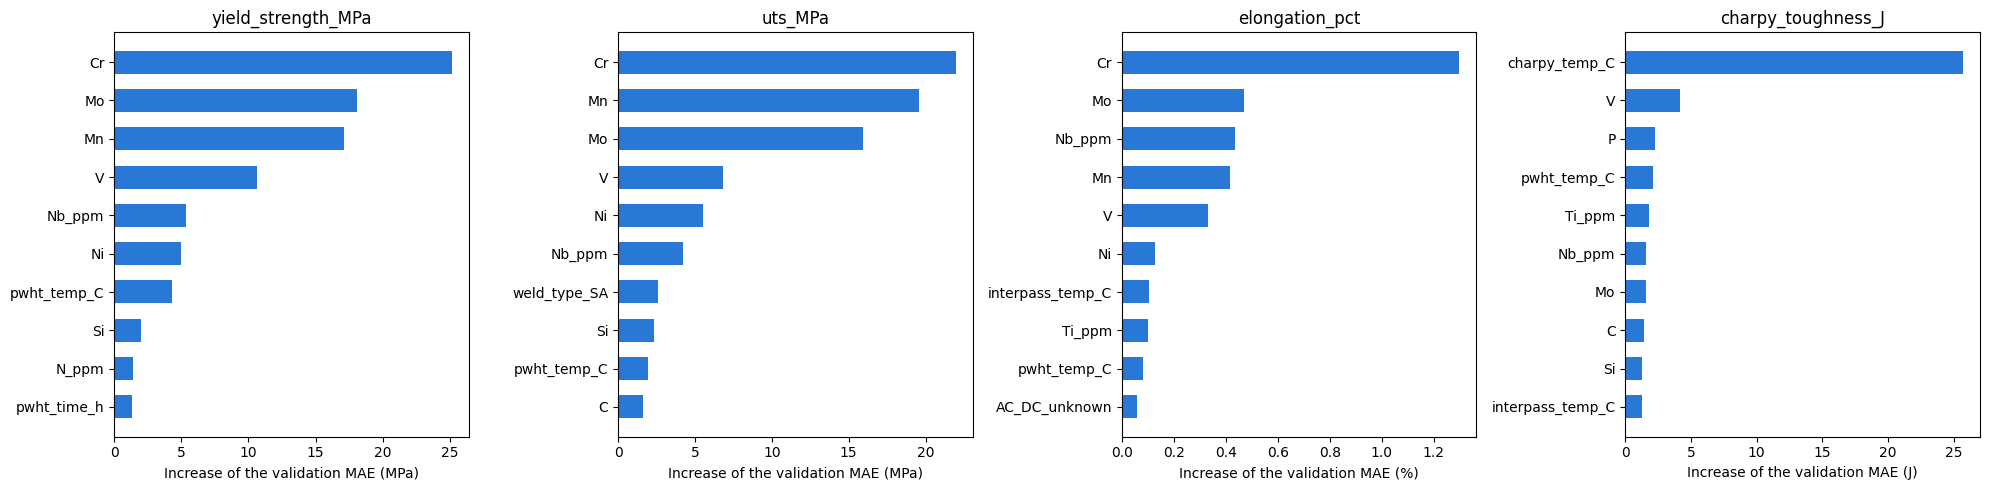

,yield_strength_MPa,uts_MPa,elongation_pct,charpy_toughness_J
charpy_temp_C,NaN,NaN,NaN,25.73
Mo,18.12,15.91,0.47,1.56
V,10.60,6.81,0.33,4.20
Nb_ppm,5.37,4.21,0.44,1.61
Mn,17.13,19.55,0.42,1.04
Cr,25.19,21.96,1.30,0.69
pwht_temp_C,4.34,1.95,0.08,2.11
Ti_ppm,1.26,1.14,0.10,1.84
Ni,4.95,5.51,0.13,0.19
Si,1.96,2.34,0.03,1.30


In [11]:
importances = {}
for target in TARGETS:
    X, y, cv = get_xy(train, target)
    per_fold = []
    for train_idx, val_idx in cv.split():
        pipe = clone(best[target]).fit(X.iloc[train_idx], y.iloc[train_idx])
        result = permutation_importance(
            pipe, X.iloc[val_idx], y.iloc[val_idx],
            scoring="neg_mean_absolute_error",
            n_repeats=10,
            random_state=SEED,
            n_jobs=-1,
        )
        per_fold.append(pd.Series(result.importances_mean, index=X.columns))
    importances[target] = pd.concat(per_fold, axis=1).mean(axis=1)
importances = pd.DataFrame(importances)

units = {"yield_strength_MPa": "MPa", "uts_MPa": "MPa", "elongation_pct": "%", "charpy_toughness_J": "J"}

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, target in zip(axes, TARGETS):
    top = importances[target].dropna().sort_values().tail(10)
    ax.barh(top.index, top.values, height=0.6, color="#2a78d6")
    ax.set_title(target)
    ax.set_xlabel(f"Increase of the validation MAE ({units[target]})")
plt.tight_layout()
plt.show()

importances.loc[importances.rank(ascending=False).mean(axis=1).sort_values().index].round(2)

The permutation importance of an input is the increase of the validation MAE when its values are shuffled between the rows of the validation fold, which breaks its link with the target. The model is fitted on the train folds and the importance computed on the validation fold (10 shuffles per input), then averaged over the 5 folds. It is in the unit of the target. The figure shows the 10 most important inputs of each target, the table every input, sorted by mean rank.

- **Tensile targets:** Cr, Mo, Mn and V come first (25.2, 18.1, 17.1 and 10.6 MPa on the yield strength). Cr and Mo separate the Cr-Mo welds and Mn hardens the C-Mn welds, as in the first splits of the pruned tree. On the elongation, Cr (1.30%) is about three times above the next input (Mo, 0.47%).
- **Charpy:** `charpy_temp_C` comes far ahead (25.7 J): the model mostly learns how the energy changes with the test temperature. The composition comes far behind (V 4.2 J, P 2.2 J, pwht_temp_C 2.1 J).
- **Welding parameters:** `current_A`, `voltage_V`, `heat_input_kJ_mm` and the `weld_type_` columns are low on every target. They are strongly correlated with each other (see the EDA notebook): when one is shuffled, the model still uses the others, so the permutation importance underrates each of them. The rare processes (GMAA, GTAA, SAA, 4 or 5 rows of the train set) are at about 0.
- **Use:** The importance tells what the model uses to predict, not the physical effect of an input on the weld.